# Bank Marketing Campaign Optimization

**Portfolio project | Python, SQL, classification, targeting strategy**

Source: [UCI Bank Marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing)  
License: CC BY 4.0 | Campaign observations: May 2008-Nov. 2010

## tl;dr

The selected **Random Forest** achieved
**0.814 ROC-AUC** and **0.487 PR-AUC**
without using post-call duration. On the holdout set, the top 20% of model-ranked
customers converted at **37.1%**
(**3.30x baseline lift**) and contained
**65.9% of subscribers**. The operational next step is
a temporal validation and randomized pilot.

## Context & Methods

**Decision:** Can a bank prioritize outbound calls more efficiently by ranking
customers using only information available before the call?

The analysis combines SQL conversion-rate cuts with two classification models.
The operational evaluation focuses on lift and responder capture in the highest-ranked
20% of customers, not accuracy, because subscriptions are relatively rare.

### Key Assumptions

- `duration` is excluded from the model because call length is only known after the call
  and would create target leakage in a pre-call targeting system.
- A stratified random holdout is used because the public file does not include a complete
  timestamp suitable for a clean temporal split.
- Model output is a prioritization score, not a causal estimate of who will subscribe
  because of being contacted.
- Sensitive or regulated production use would require fairness, calibration, monitoring,
  and compliance review beyond this portfolio analysis.

## Data

In [1]:
from pathlib import Path
import json
import sqlite3
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "data").exists():
    repository_project = PROJECT_DIR / "project_2_bank_campaign_optimization"
    if repository_project.exists():
        PROJECT_DIR = repository_project
DATA_PATH = PROJECT_DIR / "data" / "bank-additional-full.csv"
OUTPUT_DIR = PROJECT_DIR / "outputs"
CHART_DIR = OUTPUT_DIR / "charts"
OUTPUT_DIR.mkdir(exist_ok=True)
CHART_DIR.mkdir(exist_ok=True)

BLUE = "#2F6BFF"
BLUE_DARK = "#163B77"
BLUE_LIGHT = "#AFC9FF"
GOLD = "#D8A227"
INK = "#20242B"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#CDD3DA",
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": INK,
    "ytick.color": INK,
    "font.size": 10,
    "axes.titleweight": "bold",
})

In [2]:
campaign_raw = pd.read_csv(DATA_PATH, sep=";")
duplicate_rows = int(campaign_raw.duplicated().sum())
campaign = campaign_raw.drop_duplicates().copy()
campaign["subscribed"] = (campaign["y"] == "yes").astype(int)

data_profile = pd.Series({
    "Raw rows": len(campaign_raw),
    "Duplicate rows removed": duplicate_rows,
    "Analysis rows": len(campaign),
    "Features in source": campaign_raw.shape[1] - 1,
    "Subscription rate": campaign["subscribed"].mean(),
    "Rows with literal 'unknown'": int(
        (campaign.select_dtypes("object") == "unknown").any(axis=1).sum()
    ),
}, name="Source profile")
data_profile

Raw rows                      41,188.000
Duplicate rows removed            12.000
Analysis rows                 41,176.000
Features in source                20.000
Subscription rate                  0.113
Rows with literal 'unknown'   10,698.000
Name: Source profile, dtype: float64

## Results

In [3]:
db_path = OUTPUT_DIR / "bank_campaign.sqlite"
if db_path.exists():
    db_path.unlink()

with sqlite3.connect(db_path) as connection:
    campaign.to_sql("campaign", connection, index=False, if_exists="replace")

    previous_outcome_sql = '''
    SELECT
        poutcome AS previous_outcome,
        COUNT(*) AS customers,
        SUM(subscribed) AS subscribers,
        ROUND(100.0 * AVG(subscribed), 2) AS conversion_rate_pct
    FROM campaign
    GROUP BY poutcome
    ORDER BY conversion_rate_pct DESC
    '''
    previous_outcome = pd.read_sql_query(previous_outcome_sql, connection)

    job_sql = '''
    SELECT
        job,
        COUNT(*) AS customers,
        SUM(subscribed) AS subscribers,
        ROUND(100.0 * AVG(subscribed), 2) AS conversion_rate_pct
    FROM campaign
    GROUP BY job
    HAVING COUNT(*) >= 500
    ORDER BY conversion_rate_pct DESC
    '''
    job_conversion = pd.read_sql_query(job_sql, connection)

    contact_sql = '''
    SELECT
        contact,
        COUNT(*) AS customers,
        SUM(subscribed) AS subscribers,
        ROUND(100.0 * AVG(subscribed), 2) AS conversion_rate_pct
    FROM campaign
    GROUP BY contact
    ORDER BY conversion_rate_pct DESC
    '''
    contact_conversion = pd.read_sql_query(contact_sql, connection)

previous_outcome

,previous_outcome,customers,subscribers,conversion_rate_pct
0,success,1373,894,65.110
1,failure,4252,605,14.230
2,nonexistent,35551,3140,8.830


In [4]:
target = campaign["subscribed"]
leakage_columns = ["y", "subscribed", "duration"]
features = campaign.drop(columns=leakage_columns)

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.20,
    random_state=42,
    stratify=target,
)

categorical_columns = features.select_dtypes(include="object").columns.tolist()
numeric_columns = features.select_dtypes(exclude="object").columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric_columns,
        ),
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            categorical_columns,
        ),
    ]
)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1500,
        class_weight="balanced",
        random_state=42,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=220,
        max_depth=12,
        min_samples_leaf=12,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    ),
}

fitted_models = {}
model_rows = []
predictions = {}

for model_name, estimator in models.items():
    pipeline = Pipeline([
        ("preprocess", preprocess),
        ("model", estimator),
    ])
    pipeline.fit(X_train, y_train)
    probabilities = pipeline.predict_proba(X_test)[:, 1]
    predicted = (probabilities >= 0.5).astype(int)

    fitted_models[model_name] = pipeline
    predictions[model_name] = probabilities
    model_rows.append({
        "Model": model_name,
        "ROC_AUC": roc_auc_score(y_test, probabilities),
        "PR_AUC": average_precision_score(y_test, probabilities),
        "Precision_at_0.5": precision_score(y_test, predicted, zero_division=0),
        "Recall_at_0.5": recall_score(y_test, predicted, zero_division=0),
        "F1_at_0.5": f1_score(y_test, predicted, zero_division=0),
    })

model_metrics = pd.DataFrame(model_rows).sort_values("PR_AUC", ascending=False)
best_model_name = model_metrics.iloc[0]["Model"]
best_probabilities = predictions[best_model_name]
model_metrics

,Model,ROC_AUC,PR_AUC,Precision_at_0.5,Recall_at_0.5,F1_at_0.5
1,Random Forest,0.814,0.487,0.411,0.636,0.500
0,Logistic Regression,0.800,0.446,0.359,0.645,0.461


In [5]:
scored_test = pd.DataFrame({
    "actual": y_test.to_numpy(),
    "score": best_probabilities,
}).sort_values("score", ascending=False).reset_index(drop=True)

top_20_count = int(np.ceil(len(scored_test) * 0.20))
top_20 = scored_test.head(top_20_count)
overall_conversion = scored_test["actual"].mean()
top_20_conversion = top_20["actual"].mean()
top_20_lift = top_20_conversion / overall_conversion
top_20_capture = top_20["actual"].sum() / scored_test["actual"].sum()

scored_test["decile"] = pd.qcut(
    scored_test["score"].rank(method="first", ascending=False),
    q=10,
    labels=range(1, 11),
)
decile_summary = (
    scored_test.groupby("decile", observed=True)
    .agg(
        Customers=("actual", "size"),
        Subscribers=("actual", "sum"),
        ConversionRate=("actual", "mean"),
        AverageScore=("score", "mean"),
    )
    .reset_index()
)
decile_summary["CumulativeSubscribers"] = decile_summary["Subscribers"].cumsum()
decile_summary["CumulativeCapture"] = (
    decile_summary["CumulativeSubscribers"] / decile_summary["Subscribers"].sum()
)
decile_summary["RandomCapture"] = decile_summary["decile"].astype(int) / 10
decile_summary["Lift"] = decile_summary["ConversionRate"] / overall_conversion

model_metrics.to_csv(OUTPUT_DIR / "model_metrics.csv", index=False)
decile_summary.to_csv(OUTPUT_DIR / "targeting_deciles.csv", index=False)
previous_outcome.to_csv(OUTPUT_DIR / "conversion_by_previous_outcome.csv", index=False)
job_conversion.to_csv(OUTPUT_DIR / "conversion_by_job.csv", index=False)

pd.Series({
    "Selected model": best_model_name,
    "Holdout customers": len(scored_test),
    "Overall conversion rate": overall_conversion,
    "Top 20% conversion rate": top_20_conversion,
    "Top 20% lift": top_20_lift,
    "Top 20% responder capture": top_20_capture,
}, name="Targeting result")

Selected model               Random Forest
Holdout customers                     8236
Overall conversion rate              0.113
Top 20% conversion rate              0.371
Top 20% lift                         3.296
Top 20% responder capture            0.659
Name: Targeting result, dtype: object

In [6]:
logistic_pipeline = fitted_models["Logistic Regression"]
feature_names = logistic_pipeline.named_steps["preprocess"].get_feature_names_out()
coefficients = logistic_pipeline.named_steps["model"].coef_[0]
coefficient_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "AbsoluteCoefficient": np.abs(coefficients),
})
coefficient_table["Feature"] = (
    coefficient_table["Feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)
top_coefficients = coefficient_table.nlargest(16, "AbsoluteCoefficient").sort_values("Coefficient")
coefficient_table.to_csv(OUTPUT_DIR / "logistic_coefficients.csv", index=False)
top_coefficients[["Feature", "Coefficient"]]

,Feature,Coefficient
4,emp.var.rate,-2.289
48,month_jun,-0.808
50,month_may,-0.635
51,month_nov,-0.576
59,poutcome_failure,-0.355
43,contact_telephone,-0.342
29,education_illiterate,0.308
42,contact_cellular,0.310
14,job_retired,0.327
61,poutcome_success,0.336


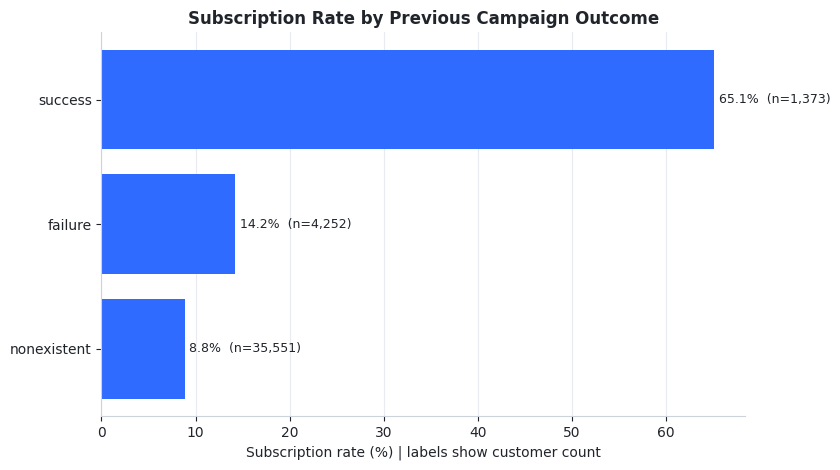

In [7]:
previous_plot = previous_outcome.sort_values("conversion_rate_pct")
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.barh(previous_plot["previous_outcome"], previous_plot["conversion_rate_pct"], color=BLUE)
ax.set_title("Subscription Rate by Previous Campaign Outcome")
ax.set_xlabel("Subscription rate (%) | labels show customer count")
ax.grid(axis="x", color="#E8EBEF", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.set_axisbelow(True)
for i, row in previous_plot.reset_index(drop=True).iterrows():
    ax.text(
        row["conversion_rate_pct"] + 0.5,
        i,
        f'{row["conversion_rate_pct"]:.1f}%  (n={int(row["customers"]):,})',
        va="center",
        fontsize=9,
    )
fig.tight_layout()
fig.savefig(CHART_DIR / "conversion_by_previous_outcome.png", dpi=180, bbox_inches="tight")
plt.show()

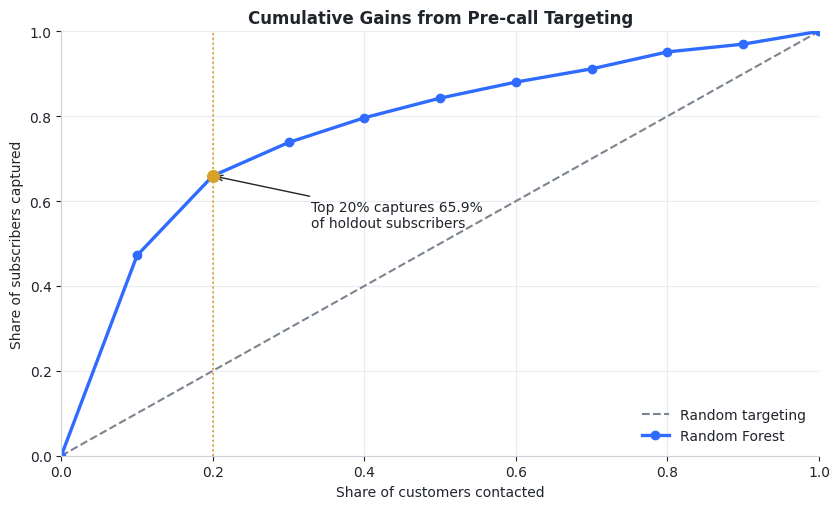

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="#7C848E",
    linewidth=1.5,
    label="Random targeting",
)
ax.plot(
    np.r_[0, decile_summary["decile"].astype(int) / 10],
    np.r_[0, decile_summary["CumulativeCapture"]],
    color=BLUE,
    marker="o",
    linewidth=2.4,
    label=best_model_name,
)
ax.axvline(0.20, color=GOLD, linewidth=1.3, linestyle=":")
ax.scatter([0.20], [top_20_capture], s=70, color=GOLD, zorder=4)
ax.annotate(
    f"Top 20% captures {top_20_capture:.1%}\nof holdout subscribers",
    xy=(0.20, top_20_capture),
    xytext=(0.33, max(0.18, top_20_capture - 0.12)),
    arrowprops={"arrowstyle": "->", "color": INK},
)
ax.set_title("Cumulative Gains from Pre-call Targeting")
ax.set_xlabel("Share of customers contacted")
ax.set_ylabel("Share of subscribers captured")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(color="#E8EBEF", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="lower right")
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(CHART_DIR / "cumulative_gains.png", dpi=180, bbox_inches="tight")
plt.show()

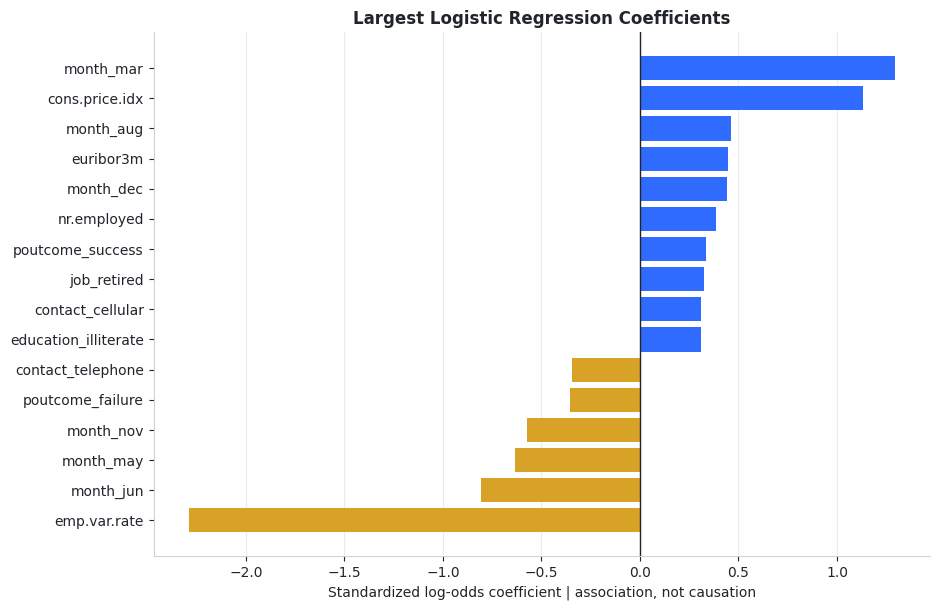

In [9]:
fig, ax = plt.subplots(figsize=(9.5, 6.2))
coefficient_colors = [BLUE if value >= 0 else GOLD for value in top_coefficients["Coefficient"]]
ax.barh(top_coefficients["Feature"], top_coefficients["Coefficient"], color=coefficient_colors)
ax.axvline(0, color=INK, linewidth=1)
ax.set_title("Largest Logistic Regression Coefficients")
ax.set_xlabel("Standardized log-odds coefficient | association, not causation")
ax.grid(axis="x", color="#E8EBEF", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(CHART_DIR / "logistic_coefficients.png", dpi=180, bbox_inches="tight")
plt.show()

In [10]:
selected_row = model_metrics.loc[model_metrics["Model"] == best_model_name].iloc[0]
validation_checks = {
    "duration_excluded": bool("duration" not in features.columns),
    "train_test_rows_reconcile": bool(len(X_train) + len(X_test) == len(campaign)),
    "target_rate_in_range": bool(0 < overall_conversion < 1),
    "probabilities_in_range": bool(((best_probabilities >= 0) & (best_probabilities <= 1)).all()),
    "decile_customers_reconcile": bool(int(decile_summary["Customers"].sum()) == len(scored_test)),
    "decile_subscribers_reconcile": bool(int(decile_summary["Subscribers"].sum()) == int(scored_test["actual"].sum())),
}
assert all(validation_checks.values()), validation_checks

summary = {
    "raw_rows": int(len(campaign_raw)),
    "duplicate_rows_removed": duplicate_rows,
    "analysis_rows": int(len(campaign)),
    "subscription_rate": float(campaign["subscribed"].mean()),
    "selected_model": best_model_name,
    "roc_auc": float(selected_row["ROC_AUC"]),
    "pr_auc": float(selected_row["PR_AUC"]),
    "top_20_conversion_rate": float(top_20_conversion),
    "top_20_lift": float(top_20_lift),
    "top_20_capture": float(top_20_capture),
    "holdout_rows": int(len(scored_test)),
    "validation_checks": validation_checks,
}
(OUTPUT_DIR / "summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
summary

{'raw_rows': 41188,
 'duplicate_rows_removed': 12,
 'analysis_rows': 41176,
 'subscription_rate': 0.11266271614532737,
 'selected_model': 'Random Forest',
 'roc_auc': 0.8139734973953909,
 'pr_auc': 0.487036573912343,
 'top_20_conversion_rate': 0.3713592233009709,
 'top_20_lift': 3.2958131067961163,
 'top_20_capture': 0.6594827586206896,
 'holdout_rows': 8236,
 'validation_checks': {'duration_excluded': True,
  'train_test_rows_reconcile': True,
  'target_rate_in_range': True,
  'probabilities_in_range': True,
  'decile_customers_reconcile': True,
  'decile_subscribers_reconcile': True}}

## Takeaways

- Use the ranking model to create a focused call list, then compare it with the
  existing campaign strategy in a randomized pilot.
- Do not use call duration for pre-call targeting; it is useful for after-call
  analysis but unavailable at the moment a call list is created.
- Prior campaign outcome is strongly associated with conversion, but the model should
  not be interpreted as proving that any customer attribute causes subscription.
- Before production use, validate performance over a later time period and review
  fairness, consent, contact-frequency limits, and model calibration.